# 07 — Post-Transforms and Kernel Comparison

**Vignette index:** | [`01` GKMKernel basics](01_basic_kernel_matrix.ipynb) | [`02` Distance metrics & kernels](02_distance_metrics_and_kernels.ipynb) | [`03` SVM with kernel](03_svc_with_kernel.ipynb) | [`04` Clustering](04_clustering_sequences.ipynb) | [`05` Long sequence scoring](05_score_long_sequence.ipynb) | [`06` Weighted (WGKM) kernel](06_weighted_kernel.ipynb) | `**07**` Transforms & comparison | [`08` Windowed 3D tensors](08_windowed_3d_tensors.ipynb) | [`09` Spectrum encoder & NB](09_spectrum_encoder_and_differential.ipynb) | [`10` Gappy encoder](10_gappy_encoder.ipynb) | [`11` Mismatch encoder](11_mismatch_encoder.ipynb) | [`12` Shuffler & chunker](12_shuffler_and_chunker.ipynb)

Visualize the 6 post-transforms with sensible parameter values, then compare GKM vs WGKM across schemes and transforms on a **centered-motif** dataset where WGKM has an advantage.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from kmer.kernels import GKMKernel, WGKMKernel
from kmer.models import KernelSVM
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

def random_seq(n, rng):
    return "".join(rng.choice(list("ACGT"), size=n))

## 1. Visualize the transform kernels

Each transform maps the normalized kernel value K ∈ [0, 1] to a new value. We use parameters that show each transform's shape clearly.

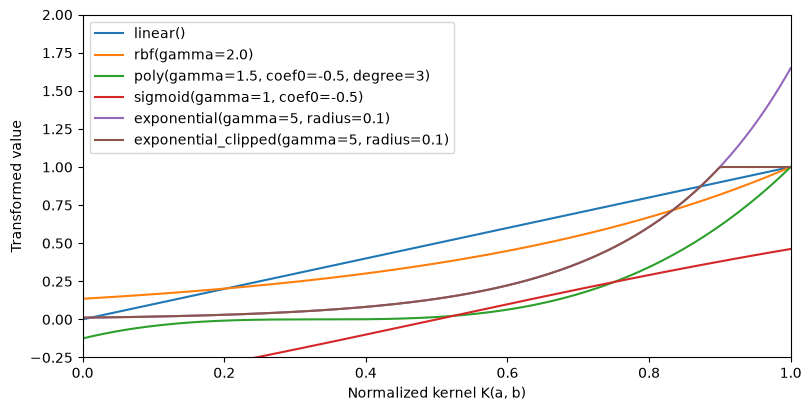

In [2]:
TRANSFORMS = {
    "linear":              lambda K, **kwargs: K,
    "rbf":                 lambda K, gamma, **kwargs: np.exp(gamma * (K - 1.0)),
    "poly":                lambda K, gamma, coef0, degree, **kwargs: (gamma * K + coef0) ** degree,
    "sigmoid":             lambda K, gamma, coef0, **kwargs: np.tanh(gamma * K + coef0),
    "exponential":         lambda K, gamma, radius, **kwargs: np.exp(-gamma * (1.0 - K - radius)),
    "exponential_clipped": lambda K, gamma, radius, **kwargs: np.exp(-gamma * np.maximum(0.0, 1.0 - K - radius)),
}

def plot_transforms(transform_type, ax=None, **kwargs):
    K = np.linspace(0, 1, 200)

    ax_none = ax is None
    if ax_none:
        fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

    param_str = ', '.join([f'{k}={v}' for k, v in kwargs.items()])
    ax.plot(K, TRANSFORMS[transform_type](K, **kwargs), label=f"{transform_type}({param_str})")
    if ax_none:
        fig.show()

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
plot_transforms('linear', ax)
plot_transforms('rbf', ax, gamma=2.0)
plot_transforms('poly', ax, gamma=1.5, coef0=-0.5, degree=3)
plot_transforms('sigmoid', ax, gamma=1, coef0=-0.5)
plot_transforms('exponential', ax, gamma=5, radius=0.1)
plot_transforms('exponential_clipped', ax, gamma=5, radius=0.1)
ax.set_xlabel("Normalized kernel K(a, b)")
ax.set_ylabel("Transformed value")
ax.set_xlim(0, 1)
ax.set_ylim(-0.25, 2)
ax.legend()
fig.show()

## 2. Centered-motif dataset

In [3]:
SEQ_LEN = 200
MOTIF = "AGATCT"
MOTIF_START = (SEQ_LEN - len(MOTIF)) // 2

rng = np.random.default_rng(42)
positives = []
for _ in range(60):
    s = list(random_seq(SEQ_LEN, rng))
    motif_start = MOTIF_START + (-1) ** rng.binomial(1, 0.5)\
                  * max(0, min(rng.poisson(10), SEQ_LEN - len(MOTIF)))
    for i, c in enumerate(MOTIF):
        s[motif_start + i] = c
    positives.append("".join(s))
negatives = [random_seq(SEQ_LEN, rng) for _ in range(60)]
seqs = positives + negatives
y = np.array([1]*60 + [0]*60)
seqs_tr, seqs_te, y_tr, y_te = train_test_split(seqs, y, test_size=0.3, stratify=y, random_state=42)

## 3. Compare schemes × transforms

In [4]:
schemes = ["full", "estimated_full", "truncated"]
transforms = ["linear", "rbf", "poly", "sigmoid", "exponential", "exponential_clipped"]

results = []
for kern_type in ["GKM", "WGKM"]:
    for scheme in schemes:
        for tf in transforms:
            if kern_type == "GKM":
                kern = GKMKernel(L=10, k=6, d=3, kernel_type=scheme, use_rc=True,
                                 transform=tf, transform_gamma=2.0, transform_coef0=1.0,
                                 transform_degree=2, transform_radius=0.1)
            else:
                kern = WGKMKernel(L=10, k=6, d=3, kernel_type=scheme, use_rc=True,
                                  weight_kernel="gaussian", weight_sigma=20.0, weight_peak=1.0,
                                  transform=tf, transform_gamma=2.0, transform_coef0=1.0,
                                  transform_degree=2, transform_radius=0.1)
            clf = KernelSVM(kern, C=1.0)
            clf.fit(seqs_tr, y_tr)
            auc = roc_auc_score(y_te, clf.decision_function(seqs_te))
            results.append((kern_type, scheme, tf, auc))

print(f"{'kernel':<5} {'scheme':<18} {'transform':<22} {'AUC':>6}")
print("-" * 55)
for r in results:
    print(f"{r[0]:<5} {r[1]:<18} {r[2]:<22} {r[3]:.3f}")

kernel scheme             transform                 AUC
-------------------------------------------------------
GKM   full               linear                 0.880
GKM   full               rbf                    0.892
GKM   full               poly                   0.889
GKM   full               sigmoid                0.889
GKM   full               exponential            0.892
GKM   full               exponential_clipped    0.892
GKM   estimated_full     linear                 0.787
GKM   estimated_full     rbf                    0.793
GKM   estimated_full     poly                   0.790
GKM   estimated_full     sigmoid                0.793
GKM   estimated_full     exponential            0.793
GKM   estimated_full     exponential_clipped    0.793
GKM   truncated          linear                 0.877
GKM   truncated          rbf                    0.886
GKM   truncated          poly                   0.880
GKM   truncated          sigmoid                0.886
GKM   truncated         

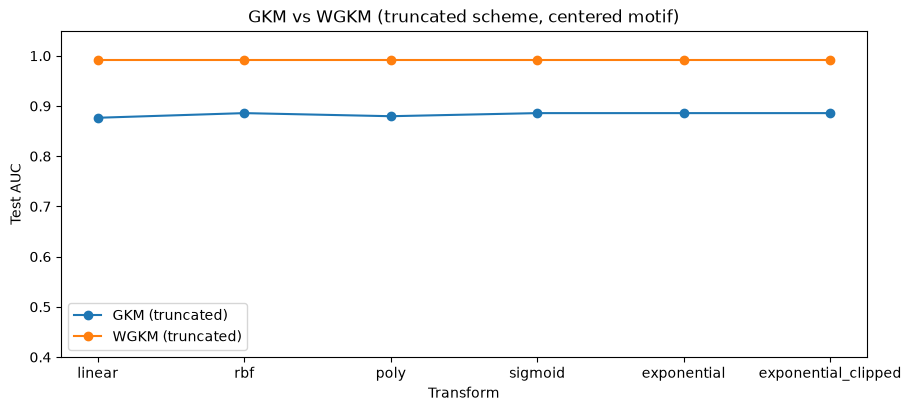

In [5]:
# Line plot of AUC by transform, grouped by kernel type
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
for kern_type in ["GKM", "WGKM"]:
    aucs = [r[3] for r in results if r[0] == kern_type and r[1] == "truncated"]
    ax.plot(transforms, aucs, marker="o", label=f"{kern_type} (truncated)")
ax.set_xlabel("Transform")
ax.set_ylabel("Test AUC")
ax.set_title("GKM vs WGKM (truncated scheme, centered motif)")
ax.legend()
ax.set_ylim(0.4, 1.05)
plt.show()